# Bayes’ Rule, Central Limit Theorem & Salary Data

This notebook explores key probability concepts in machine learning with clear examples:
- **Bayes’ rule** for updating beliefs
- The **Central Limit Theorem (CLT)**
- The **de Moivre-Laplace theorem**
- A **salary dataset** showing skewed data

We'll also explain **discrete vs continuous variables** and why they matter.

## 1. Bayes' Rule: Updating Beliefs
We’ll use Bayes’ rule to answer: If you hear thunder, how likely is it raining?
- P(Rain) = 30%
- P(Thunder | Rain) = 80%
- P(Thunder | No Rain) = 10%

In [6]:
p_rain = 0.3
p_thunder_given_rain = 0.8
p_thunder_given_no_rain = 0.1
p_thunder = p_rain * p_thunder_given_rain + (1 - p_rain) * p_thunder_given_no_rain
p_rain_given_thunder = (p_rain * p_thunder_given_rain) / p_thunder
print(f"P(Rain | Thunder): {p_rain_given_thunder:.2f}")

P(Rain | Thunder): 0.77


## 2. Central Limit Theorem (CLT)
We sample from an **exponential distribution** and plot the distribution of sample means to see the CLT in action.

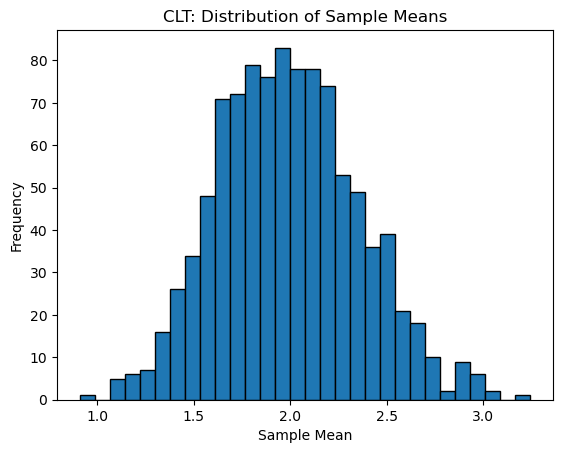

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
sample_means = [np.random.exponential(scale=2.0, size=30).mean() for _ in range(1000)]
plt.hist(sample_means, bins=30, edgecolor='black')
plt.title("CLT: Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

## 3. de Moivre-Laplace Theorem
We simulate 1000 coin flips 10,000 times and compare the histogram to a normal curve.

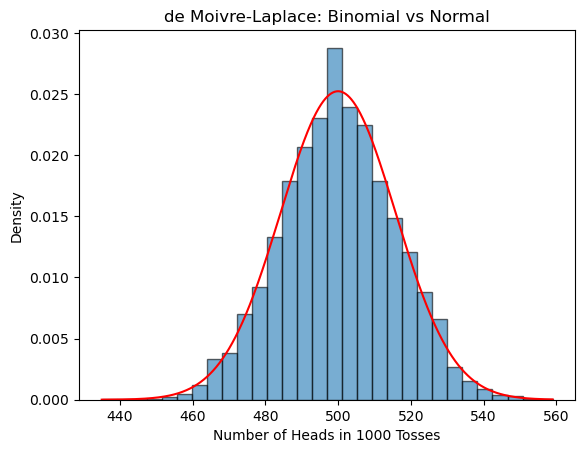

In [12]:
from scipy.stats import norm

n = 1000
p = 0.5
trials = 10000
results = np.random.binomial(n, p, size=trials)
plt.hist(results, bins=30, density=True, edgecolor='black', alpha=0.6)
mu = n * p
sigma = np.sqrt(n * p * (1 - p))
x = np.linspace(min(results), max(results), 1000)
plt.plot(x, norm.pdf(x, mu, sigma), 'r')
plt.title("de Moivre-Laplace: Binomial vs Normal")
plt.xlabel("Number of Heads in 1000 Tosses")
plt.ylabel("Density")
plt.show()

## 4. Salary Dataset Example
We create a dataset with most people earning $30k–$100k and a few earning much more, to show a **skewed distribution.**

In [ ]:
np.random.seed(42)
salaries = np.random.normal(60000, 15000, 950)
high_earners = np.random.normal(200000, 30000, 50)
all_salaries = np.concatenate([salaries, high_earners])
plt.hist(all_salaries, bins=30, edgecolor='black')
plt.title("Salary Distribution (Skewed)")
plt.xlabel("Salary")
plt.ylabel("Number of People")
plt.show()
print(f"Mean Salary: ${np.mean(all_salaries):.2f}")
print(f"Median Salary: ${np.median(all_salaries):.2f}")

## 5. Discrete vs Continuous Variables
- **Discrete**: Countable values (e.g., number of children)
- **Continuous**: Any value in a range (e.g., salary)

ML models treat these differently for accurate predictions.

## Conclusion
We saw how **Bayes’ rule** updates beliefs, the **CLT** explains normality of means, and the **de Moivre-Laplace theorem** links binomial and normal. We also explored real-world salary data and the importance of knowing **discrete vs continuous** variables in machine learning.